# Human Activity Recognition — Classical Baseline (leak-free)

Six-class activity recognition on the 561 engineered features of the UCI HAR dataset,
comparing an SVM, a fully-connected network and a 1-D CNN on PCA features.

**Leak-free evaluation protocol**
- All validation is **subject-wise** (`GroupShuffleSplit` / `StratifiedGroupKFold` on subject ID):
  no person is in both the training and validation part.
- Scaler, PCA and feature selection are **fitted inside each training split** only.
- **No SMOTE** — the classes are already close to balanced, and oversampling before splitting leaks data.
- The official test split (9 subjects never seen in training) is used **once**, in Section 11.

The raw-signal time-series model, ONNX export and INT8 quantization live in `src/`.

In [1]:
# Dependencies: pip install -r ../requirements.txt

In [2]:
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score
)

import torch
import torch.nn as nn
import torch.optim as optim

# Use GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

np.random.seed(42)
torch.manual_seed(42)

Matplotlib is building the font cache; this may take a moment.


Using device: cpu


## 1. Data Loading

In [3]:
# ------------------------------------------------------------------
# Step 1: Load the 561-feature training and test sets from the original
# UCI HAR files (see readme for the download). The official split is
# subject-disjoint: 21 subjects in train, 9 different subjects in test.
# ------------------------------------------------------------------
DATA_DIR = Path('../data/UCI HAR Dataset')

feature_names = pd.read_csv(DATA_DIR / 'features.txt', sep=r'\s+', header=None)[1]
# features.txt contains 84 duplicated names; suffix them to make columns unique
feature_names = feature_names + feature_names.groupby(feature_names).cumcount().map(
    lambda n: f'.{n}' if n else '')
activity_names = pd.read_csv(DATA_DIR / 'activity_labels.txt', sep=r'\s+',
                             header=None, index_col=0)[1]

def load_split(split):
    df = pd.read_csv(DATA_DIR / split / f'X_{split}.txt', sep=r'\s+',
                     header=None, names=list(feature_names))
    df['subject']  = np.loadtxt(DATA_DIR / split / f'subject_{split}.txt', dtype=int)
    df['Activity'] = activity_names.loc[
        np.loadtxt(DATA_DIR / split / f'y_{split}.txt', dtype=int)].values
    return df

train_data = load_split('train')
test_data  = load_split('test')
assert set(train_data['subject']).isdisjoint(test_data['subject'])

print('Training set shape:', train_data.shape)
print('Test set shape:     ', test_data.shape)

# Step 2: Inspect basic dataset properties
print('\nTraining dataset info:')
train_data.info()

# Step 3: Check for missing values and duplicates
missing = train_data.isna().sum()
print('\nMissing values:', missing[missing > 0].to_dict() or 'None')
print('Duplicate rows:', train_data.duplicated().sum())
print('Duplicate columns:', train_data.columns.duplicated().sum())

# Step 4: Summarise the target variable
print('\nUnique activities:', train_data['Activity'].unique())
print('Unique subjects:  ', sorted(train_data['subject'].unique()))
print('\nActivity distribution (training):')
activity_counts = train_data['Activity'].value_counts()
print(activity_counts)

subject_counts = train_data['subject'].value_counts()

/var/folders/7s/2p4nkzhd4ng1spbcymmxbf540000gn/T/ipykernel_9804/3676685776.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['subject']  = np.loadtxt(DATA_DIR / split / f'subject_{split}.txt', dtype=int)
/var/folders/7s/2p4nkzhd4ng1spbcymmxbf540000gn/T/ipykernel_9804/3676685776.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Activity'] = activity_names.loc[


Training set shape: (7352, 563)
Test set shape:      (2947, 563)

Training dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), str(1)
memory usage: 31.6 MB

Missing values: None
Duplicate rows: 0
Duplicate columns: 0

Unique activities: <ArrowStringArray>
[          'STANDING',            'SITTING',             'LAYING',
            'WALKING', 'WALKING_DOWNSTAIRS',   'WALKING_UPSTAIRS']
Length: 6, dtype: str
Unique subjects:   [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]

Activity distribution (training):
Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS   

/var/folders/7s/2p4nkzhd4ng1spbcymmxbf540000gn/T/ipykernel_9804/3676685776.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['subject']  = np.loadtxt(DATA_DIR / split / f'subject_{split}.txt', dtype=int)
/var/folders/7s/2p4nkzhd4ng1spbcymmxbf540000gn/T/ipykernel_9804/3676685776.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Activity'] = activity_names.loc[


## 2. Exploratory Data Analysis

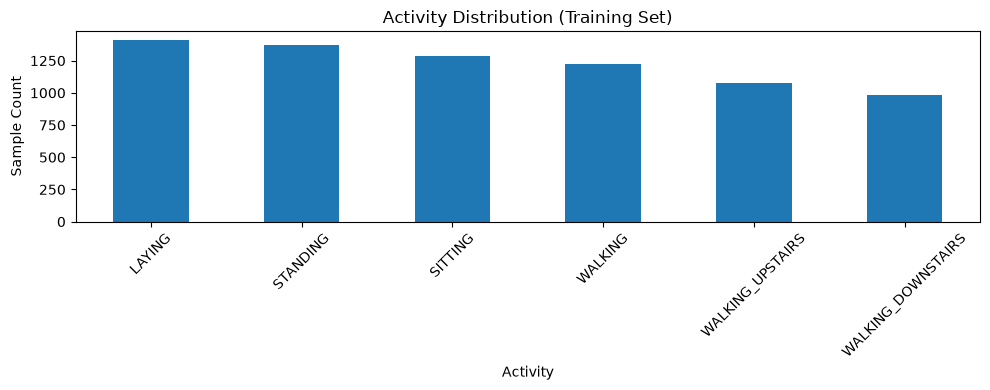

In [4]:
# Distribution of activity labels in the training set
plt.figure(figsize=(10, 4))
activity_counts.plot(kind='bar')
plt.title('Activity Distribution (Training Set)')
plt.xlabel('Activity')
plt.ylabel('Sample Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


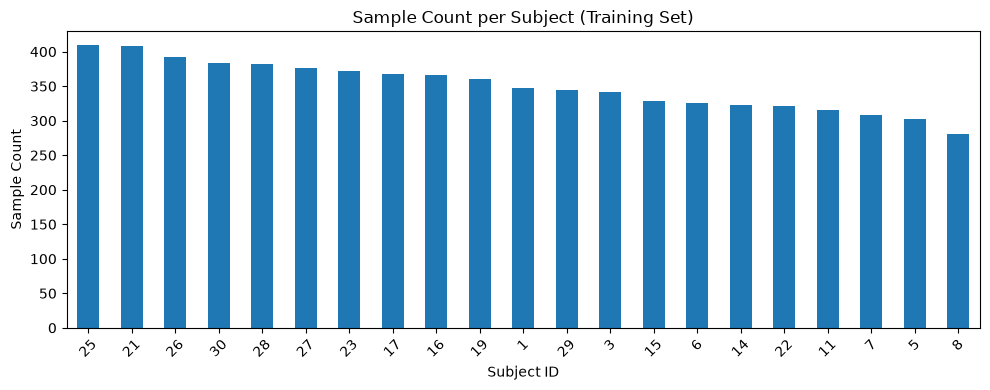

In [5]:
# Number of samples contributed by each subject
plt.figure(figsize=(10, 4))
subject_counts.plot(kind='bar')
plt.title('Sample Count per Subject (Training Set)')
plt.xlabel('Subject ID')
plt.ylabel('Sample Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


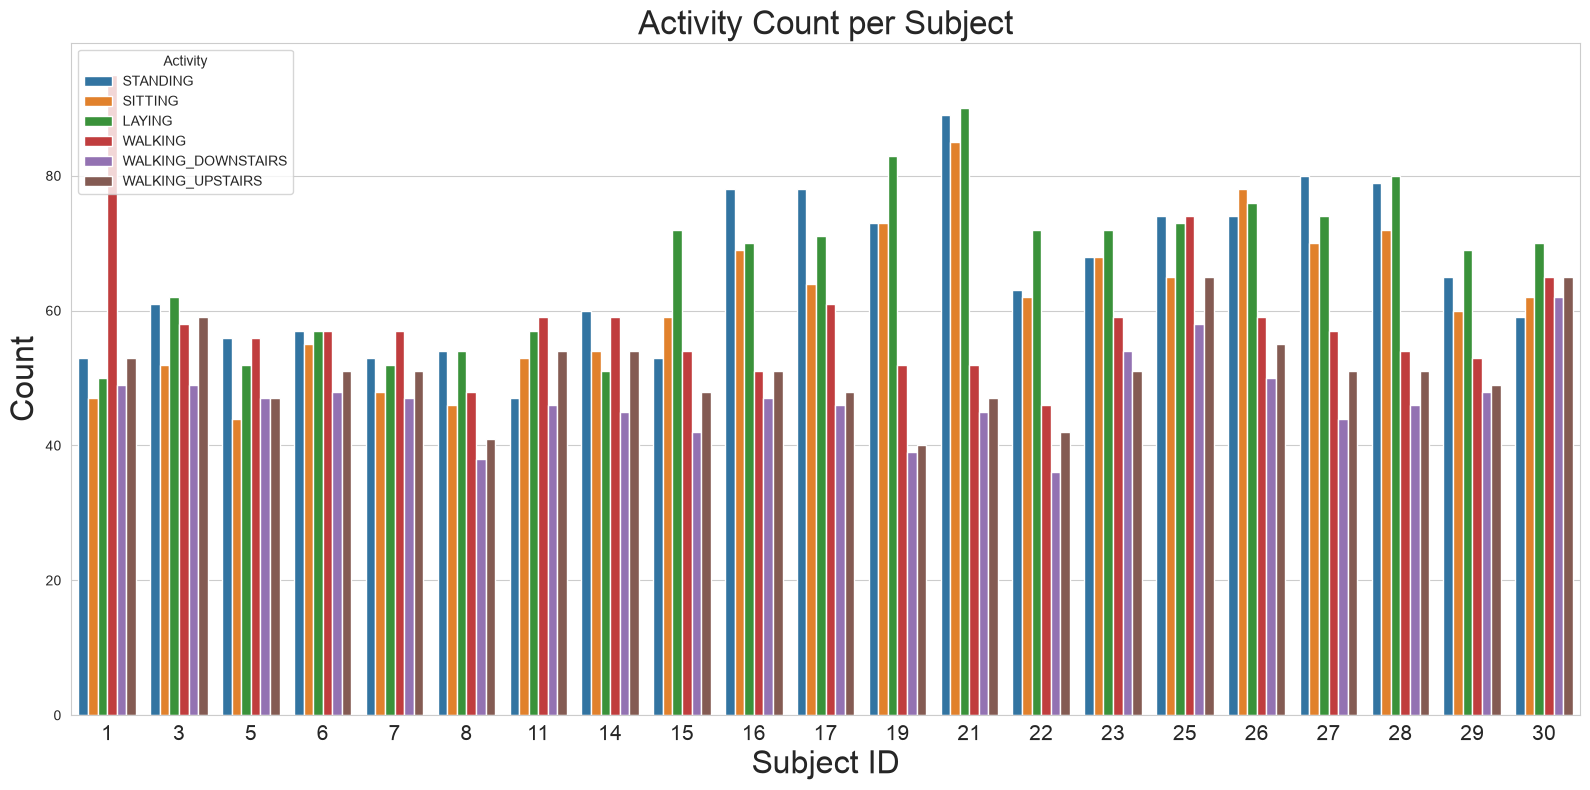

In [6]:
# Activity breakdown per subject — shows how activities are distributed
# across individual participants
plt.figure(figsize=(16, 8))
sns.set_style('whitegrid')
sns.color_palette('tab10')
sns.countplot(x='subject', hue='Activity', data=train_data)
plt.title('Activity Count per Subject', fontsize=24)
plt.xlabel('Subject ID', size=23)
plt.ylabel('Count', size=23)
plt.xticks(size=15)
plt.tight_layout()
plt.show()


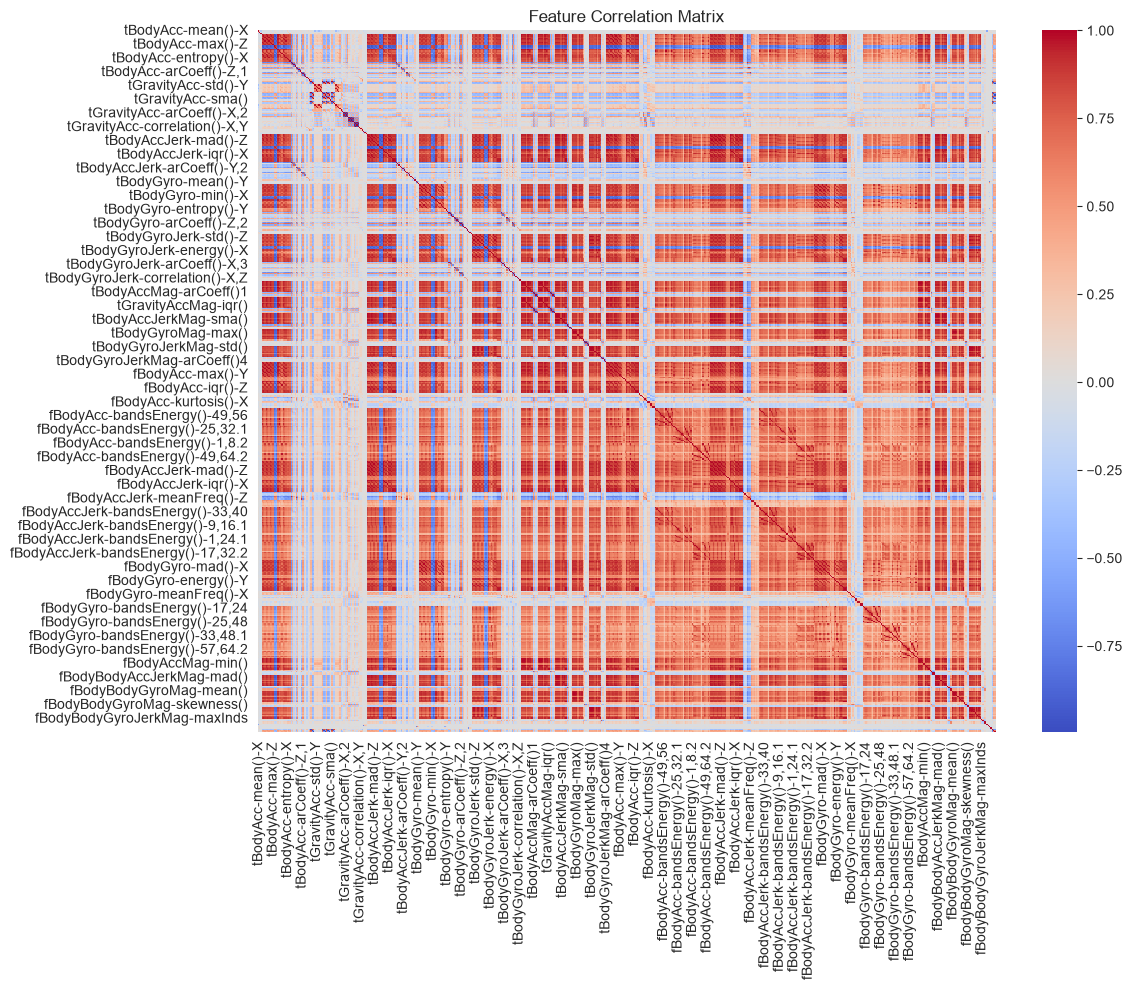

In [7]:
# Correlation heatmap of the 561 sensor features.
# High inter-feature correlation motivates PCA dimensionality reduction.
correlation_matrix = train_data.drop(['Activity', 'subject'], axis=1).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## 3. Preprocessing — Label Encoding, Scaling & Subject-Wise Splits

In [8]:
# ------------------------------------------------------------------
# Leak-free protocol used throughout this notebook:
#  * Validation is always subject-wise: no person appears in both the
#    training and validation part. Windows from one person are highly
#    correlated and overlap by 50%, so random splits inflate accuracy.
#  * Scaler / PCA / feature selection are fitted on the training part of
#    each split only (sklearn Pipelines, per-fold refits for the neural nets).
#  * No SMOTE: classes are already close to balanced, and oversampling
#    before splitting leaks validation points into training.
#  * The official test set (9 unseen subjects) is used once, at the end.
# ------------------------------------------------------------------

# Step 1: Separate features, target label and subject IDs
X_raw    = train_data.drop(columns=['Activity', 'subject'])
y_raw    = train_data['Activity']
subjects = train_data['subject'].values

# Step 2: Encode string activity labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
print('Encoded classes:', list(le.classes_))
print('Class counts:   ', dict(zip(le.classes_, np.bincount(y_encoded))))

# Step 3: Standardise on the full training set. Used for the PCA analysis
# and for the final models evaluated on the test set; validation
# experiments refit the scaler inside each split.
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Step 4: Subject-wise 80/20 hold-out split for quick validation
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, va_idx = next(gss.split(X_raw, y_encoded, groups=subjects))
assert set(subjects[tr_idx]).isdisjoint(subjects[va_idx])
print(f'\nHold-out split: {len(set(subjects[tr_idx]))} train subjects ({len(tr_idx)} windows) | '
      f'{len(set(subjects[va_idx]))} val subjects ({len(va_idx)} windows)')

# Step 5: 5-fold subject-wise cross-validation splitter shared by all models
cv_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

Encoded classes: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
Class counts:    {'LAYING': np.int64(1407), 'SITTING': np.int64(1286), 'STANDING': np.int64(1374), 'WALKING': np.int64(1226), 'WALKING_DOWNSTAIRS': np.int64(986), 'WALKING_UPSTAIRS': np.int64(1073)}

Hold-out split: 16 train subjects (5551 windows) | 5 val subjects (1801 windows)


## 4. Dimensionality Reduction (PCA)

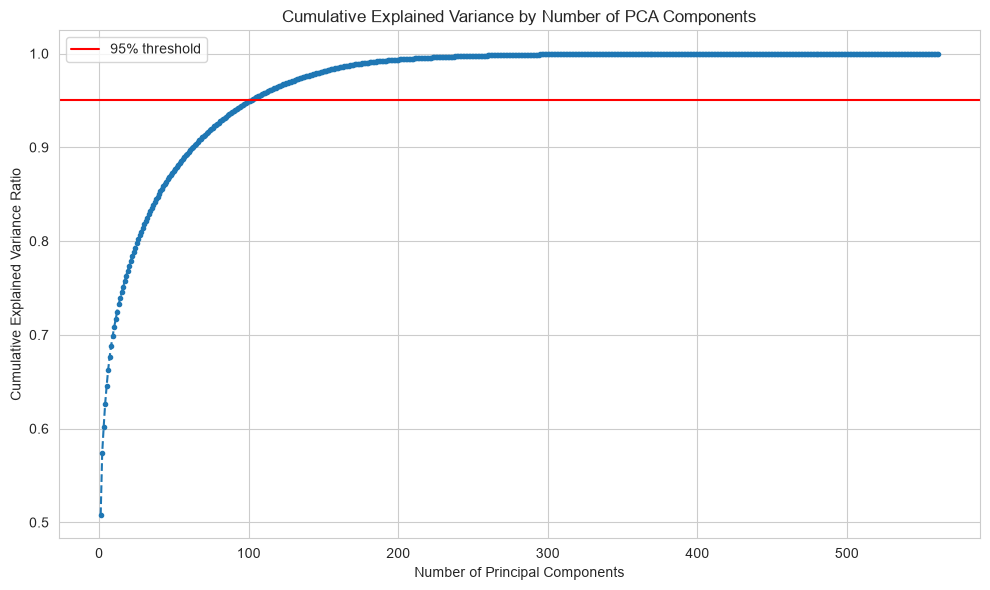

Components needed to explain 95% of variance: 102


In [9]:
# ------------------------------------------------------------------
# Step 1: Standardised training features (from Section 3)
# ------------------------------------------------------------------
scaled_features = X_scaled

# Step 2: Fit a full PCA to inspect cumulative explained variance
pca_full = PCA(n_components=None)
pca_full.fit_transform(scaled_features)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Step 3: Plot cumulative explained variance to choose n_components
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         marker='o', linestyle='--', markersize=3)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% threshold')
plt.title('Cumulative Explained Variance by Number of PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.legend()
plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'Components needed to explain 95% of variance: {n_components_95}')

In [10]:
# ------------------------------------------------------------------
# Step 1: Fit PCA with the chosen number of components (100)
# and transform the full training set (used by the final models).
# ------------------------------------------------------------------
N_COMPONENTS = 100
pca_95 = PCA(n_components=N_COMPONENTS)
pca_result = pca_95.fit_transform(scaled_features)
print(f'Transformed training set shape: {pca_result.shape}')

# Step 2: Wrap the PCA output in a DataFrame for easier manipulation
pca_columns = [f'PC{i+1}' for i in range(N_COMPONENTS)]
pca_df = pd.DataFrame(data=pca_result, columns=pca_columns)

# Step 3: Attach integer-encoded activity labels
pca_df['Activity'] = y_encoded

print('Encoded class mapping:', dict(enumerate(le.classes_)))
print(pca_df.head())

Transformed training set shape: (7352, 100)
Encoded class mapping: {0: 'LAYING', 1: 'SITTING', 2: 'STANDING', 3: 'WALKING', 4: 'WALKING_DOWNSTAIRS', 5: 'WALKING_UPSTAIRS'}
         PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -16.138544  2.152024 -3.144780  0.272464 -6.798938 -4.249394  2.937159   
1 -15.296194  1.387144  0.682221 -2.813677 -4.266170 -2.055663  0.011205   
2 -15.137019  2.473351  1.756641 -3.717974 -4.181557 -1.357518  0.072947   
3 -15.350884  3.915681  1.790322 -2.567521 -3.205840 -0.942944  0.530736   
4 -15.544814  4.598737  2.188582 -2.897578 -3.080150 -1.061458 -1.048591   

        PC8       PC9      PC10  ...      PC92      PC93      PC94      PC95  \
0 -4.905413  0.775515  3.627737  ... -0.873826  1.835069 -0.165438 -1.318898   
1 -1.845985 -0.492546  0.180175  ... -0.007449 -0.982101 -0.446051 -0.683640   
2 -1.388188 -0.539754  0.671712  ... -0.013442  0.961786  0.194423  0.488807   
3 -1.832185 -1.071517  1.496989  ... -0.734062 -1.3

## 5. SVM Classification

In [11]:
# ------------------------------------------------------------------
# Step 1: Build the SVM as a pipeline so that scaling and PCA are
# fitted on the training subjects only, never on validation subjects.
# ------------------------------------------------------------------
def make_svm_pipeline(n_components=N_COMPONENTS):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=n_components)),
        ('svm',    SVC(kernel='rbf', C=1, gamma='scale', random_state=42)),
    ])

# Step 2: Subject-wise hold-out split (from Section 3)
X_train, X_val = X_raw.iloc[tr_idx], X_raw.iloc[va_idx]
y_train, y_val = y_encoded[tr_idx], y_encoded[va_idx]
print(f'Train size: {len(X_train)} | Val size: {len(X_val)}')

# Step 3: Train an RBF-kernel SVM (C=1, gamma='scale' are sklearn defaults)
svm_model = make_svm_pipeline()
svm_model.fit(X_train, y_train)
print('SVM training complete.')

Train size: 5551 | Val size: 1801


SVM training complete.


                    precision    recall  f1-score   support

            LAYING       1.00      0.94      0.97       331
           SITTING       0.93      0.97      0.95       293
          STANDING       0.98      0.94      0.96       321
           WALKING       0.99      1.00      1.00       338
WALKING_DOWNSTAIRS       0.93      0.79      0.86       242
  WALKING_UPSTAIRS       0.84      1.00      0.92       276

          accuracy                           0.95      1801
         macro avg       0.95      0.94      0.94      1801
      weighted avg       0.95      0.95      0.95      1801



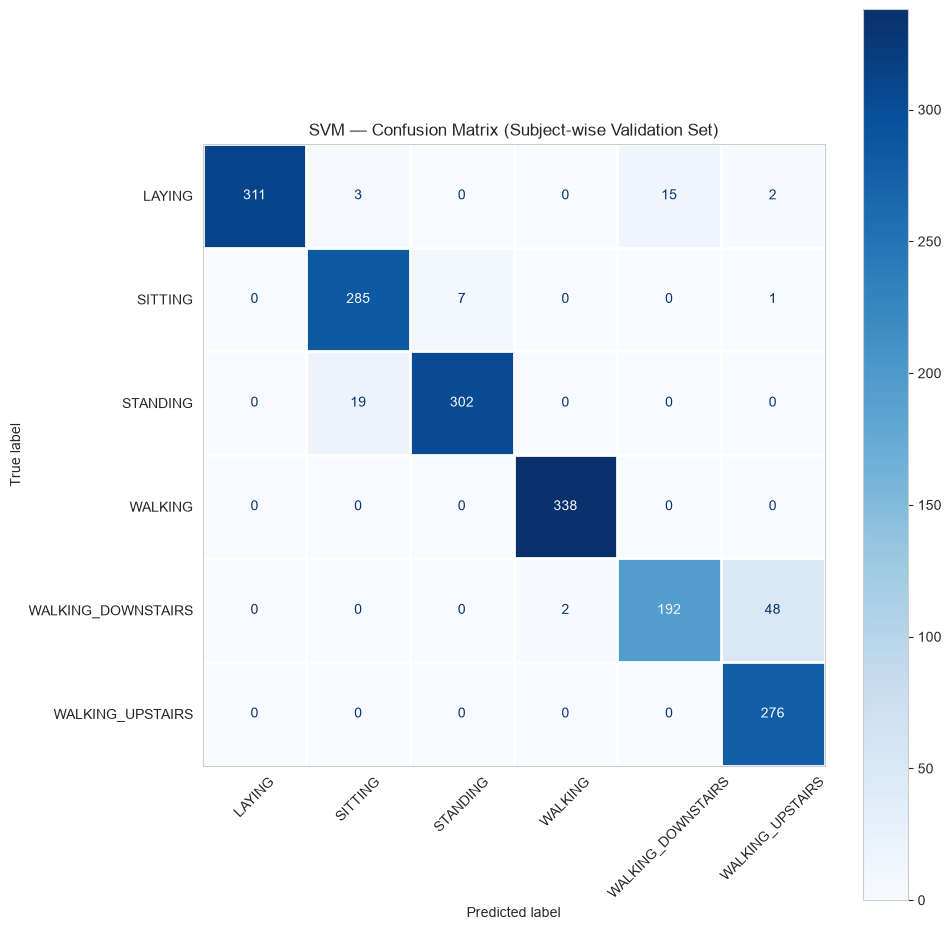

SVM Validation Accuracy : 0.9461
SVM Validation F1 Score : 0.9458


In [12]:
# ------------------------------------------------------------------
# Step 1: Generate predictions on the validation split
# ------------------------------------------------------------------
y_pred_svm = svm_model.predict(X_val)

# Step 2: Per-class classification report
print(classification_report(y_val, y_pred_svm, target_names=le.classes_))

# Step 3: Confusion matrix
cm = confusion_matrix(y_val, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title('SVM — Confusion Matrix (Subject-wise Validation Set)')
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', size=0)
plt.tight_layout()
plt.show()

# Step 4: Summary metrics
svm_accuracy = accuracy_score(y_val, y_pred_svm)
svm_f1       = f1_score(y_val, y_pred_svm, average='weighted')
print(f'SVM Validation Accuracy : {svm_accuracy:.4f}')
print(f'SVM Validation F1 Score : {svm_f1:.4f}')

### Subject-wise 5-fold cross-validation

In [13]:
# ------------------------------------------------------------------
# Leak-free CV estimate: every fold holds out whole subjects and the
# pipeline (scaler + PCA + SVM) is refitted from scratch on each fold.
# ------------------------------------------------------------------
svm_cv = cross_validate(make_svm_pipeline(), X_raw, y_encoded,
                        groups=subjects, cv=cv_splitter,
                        scoring=['accuracy', 'f1_macro'], n_jobs=-1)
svm_cv_acc = svm_cv['test_accuracy']
svm_cv_f1  = svm_cv['test_f1_macro']

print('Per-fold accuracy:', np.round(svm_cv_acc, 4))
print(f'SVM subject-wise CV accuracy : {svm_cv_acc.mean():.4f} ± {svm_cv_acc.std():.4f}')
print(f'SVM subject-wise CV macro-F1 : {svm_cv_f1.mean():.4f} ± {svm_cv_f1.std():.4f}')

Per-fold accuracy: [0.9162 0.9247 0.8955 0.846  0.966 ]
SVM subject-wise CV accuracy : 0.9097 ± 0.0392
SVM subject-wise CV macro-F1 : 0.9096 ± 0.0375


## 6. Fully-Connected Neural Network

In [14]:
# ------------------------------------------------------------------
# Helpers shared by the SimpleNN and CNN experiments
# ------------------------------------------------------------------
num_classes = len(le.classes_)

def fold_pca_features(train_idx, val_idx, n_components=N_COMPONENTS):
    """Fit scaler + PCA on the training fold only, then transform both folds."""
    prep = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=n_components))])
    return prep.fit_transform(X_raw.iloc[train_idx]), prep.transform(X_raw.iloc[val_idx])


def cross_validate_torch(build_model, name, add_channel_dim=False,
                         num_epochs=100, patience=5):
    """Subject-wise CV for a PyTorch model on per-fold PCA features.

    Returns per-fold accuracy and macro-F1, the best epoch of each fold
    (used to size the final training run) and pooled out-of-fold predictions.
    """
    fold_acc, fold_f1, best_epochs = [], [], []
    oof_pred = np.zeros_like(y_encoded)

    for fold, (train_idx, val_idx) in enumerate(
            cv_splitter.split(X_raw, y_encoded, groups=subjects), start=1):
        X_tr, X_va = fold_pca_features(train_idx, val_idx)
        X_tr = torch.tensor(X_tr, dtype=torch.float32).to(device)
        X_va = torch.tensor(X_va, dtype=torch.float32).to(device)
        if add_channel_dim:                      # (N, 100) -> (N, 1, 100)
            X_tr, X_va = X_tr.unsqueeze(1), X_va.unsqueeze(1)
        y_tr = torch.tensor(y_encoded[train_idx], dtype=torch.long).to(device)
        y_va = torch.tensor(y_encoded[val_idx],   dtype=torch.long).to(device)

        torch.manual_seed(42)
        model     = build_model().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        best_val_loss, best_epoch, patience_counter = float('inf'), 0, 0
        best_model_wts = None
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

        for epoch in range(num_epochs):
            model.train()
            optimizer.zero_grad()
            criterion(model(X_tr), y_tr).backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                tr_out, va_out = model(X_tr), model(X_va)
                val_loss = criterion(va_out, y_va).item()
                history['train_loss'].append(criterion(tr_out, y_tr).item())
                history['val_loss'].append(val_loss)
                history['train_acc'].append((tr_out.argmax(1) == y_tr).float().mean().item())
                history['val_acc'].append((va_out.argmax(1) == y_va).float().mean().item())

            if val_loss < best_val_loss:
                best_val_loss, best_epoch, patience_counter = val_loss, epoch + 1, 0
                # deepcopy: state_dict() returns live tensors that keep training
                best_model_wts = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f'  Early stopping at epoch {epoch + 1}')
                    break

        # Evaluate the restored best weights on the held-out subjects
        model.load_state_dict(best_model_wts)
        model.eval()
        with torch.no_grad():
            val_pred = model(X_va).argmax(1).cpu().numpy()
        oof_pred[val_idx] = val_pred
        acc = accuracy_score(y_encoded[val_idx], val_pred)
        f1  = f1_score(y_encoded[val_idx], val_pred, average='macro')
        fold_acc.append(acc)
        fold_f1.append(f1)
        best_epochs.append(best_epoch)
        print(f'--- Fold {fold} | val subjects {sorted(set(subjects[val_idx]))} | '
              f'best epoch {best_epoch} | Val Acc {acc:.4f} | Val macro-F1 {f1:.4f}')

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        for ax, key, label in [(axes[0], 'loss', 'Cross-Entropy Loss'), (axes[1], 'acc', 'Accuracy')]:
            ax.plot(history[f'train_{key}'], label='Train')
            ax.plot(history[f'val_{key}'],   label='Val')
            ax.set_title(f'{name} — Fold {fold} — {label}')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(label)
            ax.legend()
        plt.tight_layout()
        plt.show()

    fold_acc, fold_f1 = np.array(fold_acc), np.array(fold_f1)
    print(f'\n{name} subject-wise CV accuracy : {fold_acc.mean():.4f} ± {fold_acc.std():.4f}')
    print(f'{name} subject-wise CV macro-F1 : {fold_f1.mean():.4f} ± {fold_f1.std():.4f}')
    return fold_acc, fold_f1, best_epochs, oof_pred


def train_final_model(model, X, y, n_epochs):
    """Train on all training subjects for a fixed number of epochs (chosen by CV)."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    for _ in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        criterion(model(X), y).backward()
        optimizer.step()
    return model.eval()


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.xticks(rotation=45)
    plt.title(title)
    ax.grid(False)
    plt.tight_layout()
    plt.show()

In [15]:
class SimpleNN(nn.Module):
    """
    Three-layer fully-connected classifier.
    Architecture: Linear(input→128) → ReLU → Dropout(0.5)
                  → Linear(128→64) → ReLU → Dropout(0.5)
                  → Linear(64→num_classes)
    """
    def __init__(self, input_size: int, num_classes: int):
        super().__init__()
        self.fc1     = nn.Linear(input_size, 128)
        self.fc2     = nn.Linear(128, 64)
        self.fc3     = nn.Linear(64, num_classes)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        return self.fc3(x)


  Early stopping at epoch 97
--- Fold 1 | val subjects [np.int64(15), np.int64(21), np.int64(25), np.int64(30)] | best epoch 92 | Val Acc 0.9254 | Val macro-F1 0.9213


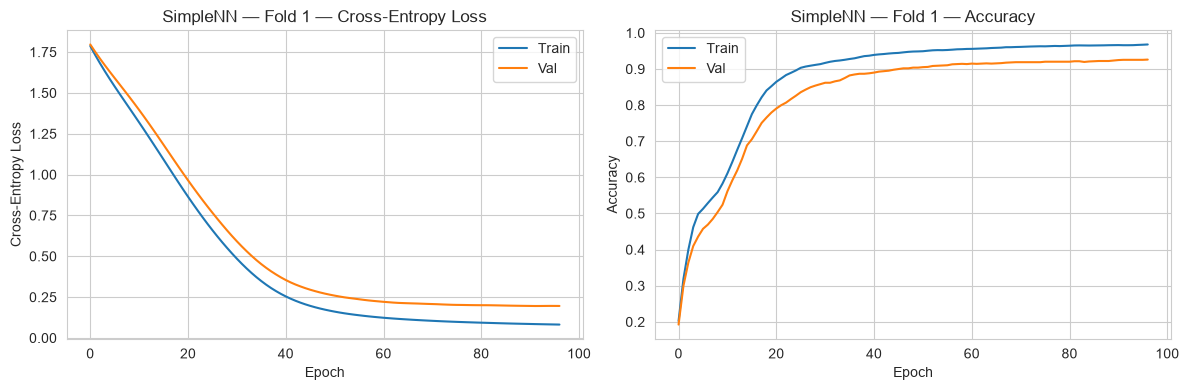

  Early stopping at epoch 71
--- Fold 2 | val subjects [np.int64(7), np.int64(8), np.int64(11), np.int64(17), np.int64(19)] | best epoch 66 | Val Acc 0.9296 | Val macro-F1 0.9291


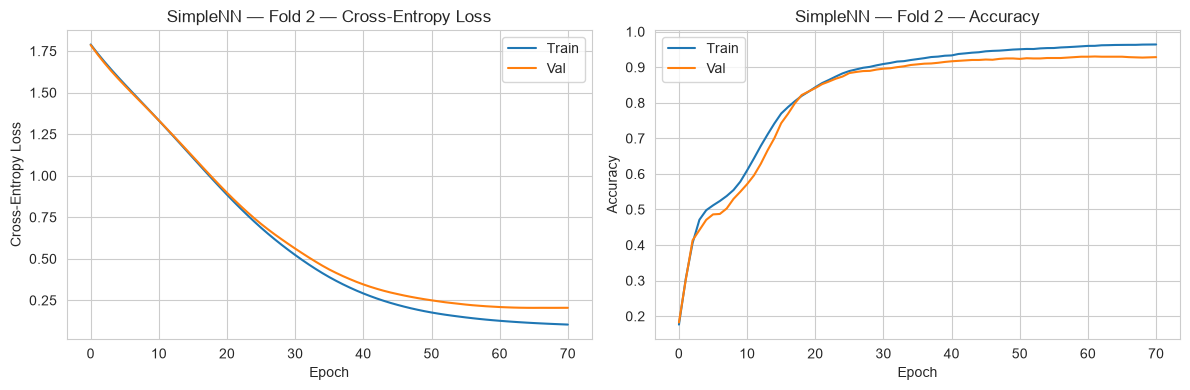

  Early stopping at epoch 72
--- Fold 3 | val subjects [np.int64(1), np.int64(5), np.int64(16), np.int64(23)] | best epoch 67 | Val Acc 0.8983 | Val macro-F1 0.9026


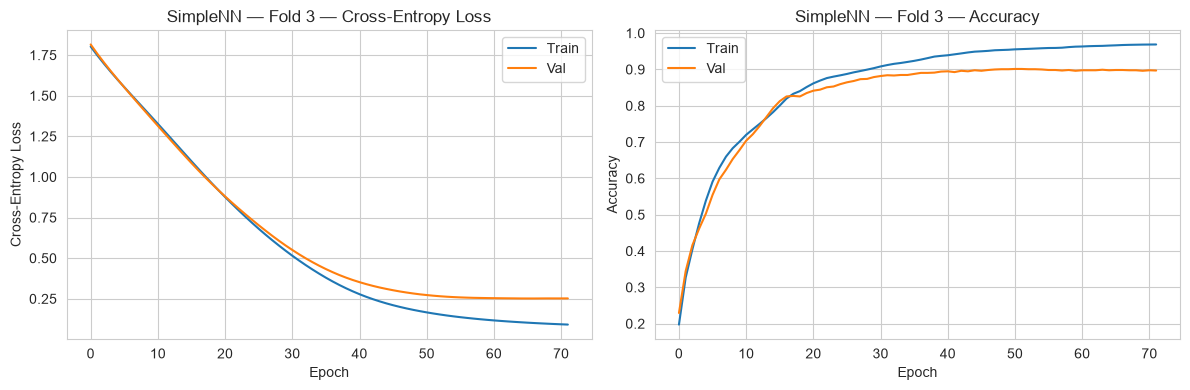

  Early stopping at epoch 53
--- Fold 4 | val subjects [np.int64(6), np.int64(14), np.int64(26), np.int64(28)] | best epoch 48 | Val Acc 0.8150 | Val macro-F1 0.8181


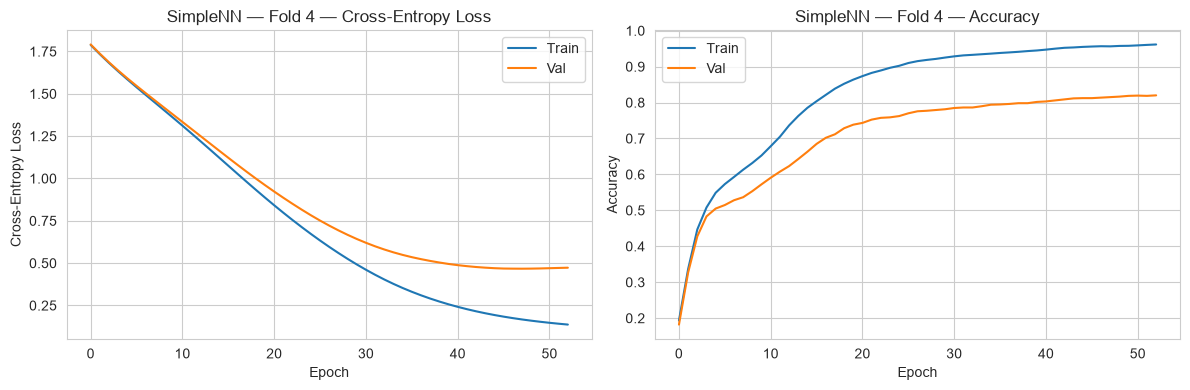

--- Fold 5 | val subjects [np.int64(3), np.int64(22), np.int64(27), np.int64(29)] | best epoch 100 | Val Acc 0.9674 | Val macro-F1 0.9679


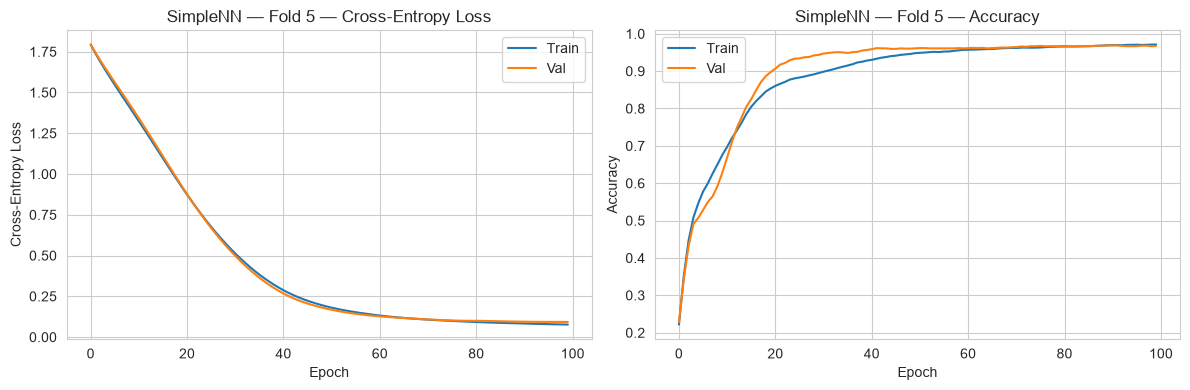


SimpleNN subject-wise CV accuracy : 0.9072 ± 0.0511
SimpleNN subject-wise CV macro-F1 : 0.9078 ± 0.0496


In [16]:
# ------------------------------------------------------------------
# 5-fold subject-wise cross-validation for SimpleNN.
# Scaler + PCA are refitted on each training fold; early stopping
# picks the best epoch per fold.
# ------------------------------------------------------------------
nn_cv_acc, nn_cv_f1, nn_best_epochs, nn_oof_pred = cross_validate_torch(
    lambda: SimpleNN(N_COMPONENTS, num_classes), 'SimpleNN')

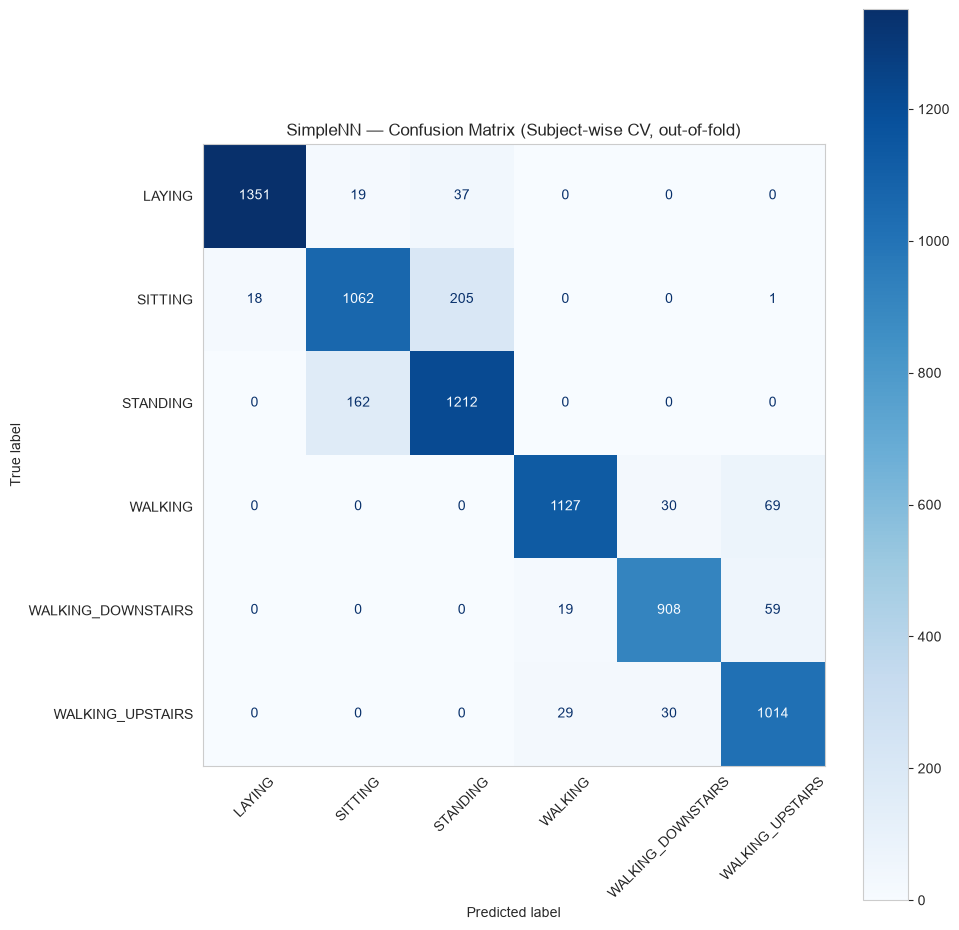

Final SimpleNN trained for 67 epochs on all 7352 training windows.


In [17]:
# ------------------------------------------------------------------
# Step 1: Confusion matrix of the pooled out-of-fold predictions — every
# training window predicted by a model that never saw its subject.
# ------------------------------------------------------------------
plot_confusion(y_encoded, nn_oof_pred, 'SimpleNN — Confusion Matrix (Subject-wise CV, out-of-fold)')

# Step 2: Train the final SimpleNN on all training subjects for the median
# best epoch found in CV, on the full-train scaler + PCA features (pca_df).
# This is the model evaluated on the test set.
nn_epochs = int(np.median(nn_best_epochs))
X_all = torch.tensor(pca_df.drop(['Activity'], axis=1).values, dtype=torch.float32).to(device)
y_all = torch.tensor(y_encoded, dtype=torch.long).to(device)
torch.manual_seed(42)
final_nn = train_final_model(SimpleNN(N_COMPONENTS, num_classes).to(device), X_all, y_all, nn_epochs)
torch.save(final_nn.state_dict(), 'best_model_NN.pth')
print(f'Final SimpleNN trained for {nn_epochs} epochs on all {len(y_all)} training windows.')

## 7. 1-D Convolutional Neural Network

In [18]:
# ------------------------------------------------------------------
# The CNN expects input shape (batch, channels, length).
# We treat each PCA-reduced sample as a 1-channel 1-D signal.
# These full-training-set tensors are used for the final CNN.
# ------------------------------------------------------------------
X_cnn = pca_df.drop(['Activity'], axis=1).values
y_cnn = pca_df['Activity'].values

# unsqueeze(1) adds the channel dimension: (N, 100) → (N, 1, 100)
X_tensor = torch.tensor(X_cnn, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(y_cnn, dtype=torch.long)

print(f'X_tensor shape: {X_tensor.shape}')  # Expected: (N, 1, 100)
print(f'y_tensor shape: {y_tensor.shape}')

X_tensor shape: torch.Size([7352, 1, 100])
y_tensor shape: torch.Size([7352])


In [19]:
class SimpleCNN(nn.Module):
    """
    Lightweight 1-D CNN for sequence classification.
    Architecture:
      Conv1d(1→32, k=3) → ReLU → MaxPool(2)
      Conv1d(32→64, k=3) → ReLU → MaxPool(2)
      Flatten → Linear(1600→128) → ReLU → Dropout(0.5)
      Linear(128→num_classes)
    The fc1 input size assumes input_size=100 (100 PCA components):
      100 → MaxPool → 50 → MaxPool → 25 ; 25 * 64 channels = 1600
    """
    def __init__(self, input_size: int, num_classes: int):
        super().__init__()
        self.conv1   = nn.Conv1d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2   = nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1)
        self.relu    = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)
        # After two MaxPool(2) operations the length is input_size // 4
        self.fc1 = nn.Linear(input_size * 64 // 4, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.maxpool(self.relu(self.conv1(x)))  # (B, 32, L/2)
        x = self.maxpool(self.relu(self.conv2(x)))  # (B, 64, L/4)
        x = x.view(x.size(0), -1)                   # Flatten
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)


  Early stopping at epoch 59


--- Fold 1 | val subjects [np.int64(15), np.int64(21), np.int64(25), np.int64(30)] | best epoch 54 | Val Acc 0.8855 | Val macro-F1 0.8794


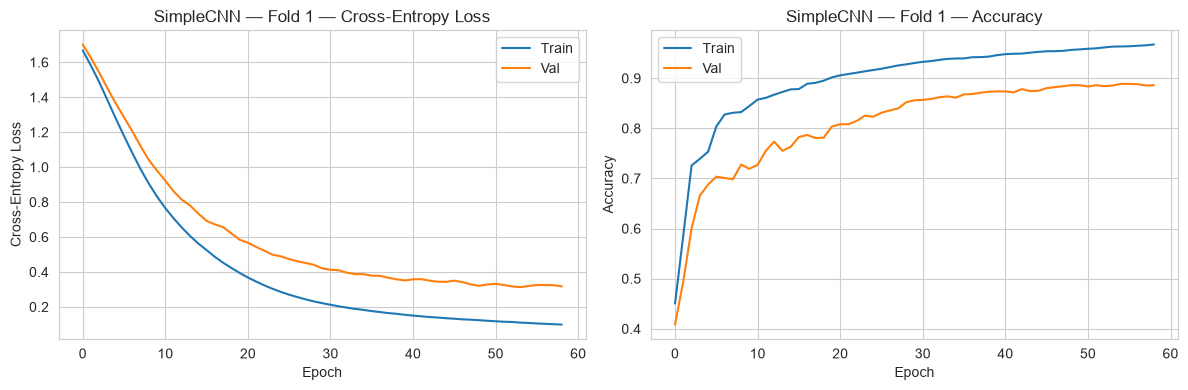

  Early stopping at epoch 58


--- Fold 2 | val subjects [np.int64(7), np.int64(8), np.int64(11), np.int64(17), np.int64(19)] | best epoch 53 | Val Acc 0.8830 | Val macro-F1 0.8784


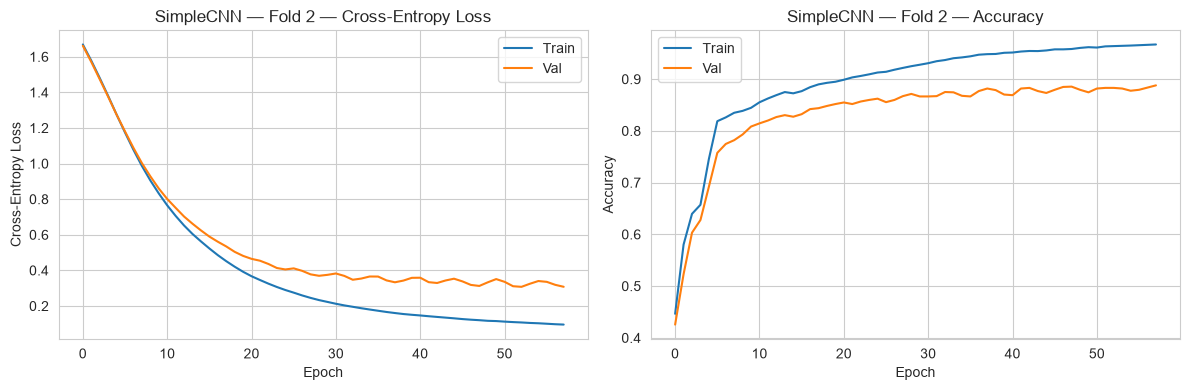

  Early stopping at epoch 45


--- Fold 3 | val subjects [np.int64(1), np.int64(5), np.int64(16), np.int64(23)] | best epoch 40 | Val Acc 0.8428 | Val macro-F1 0.8440


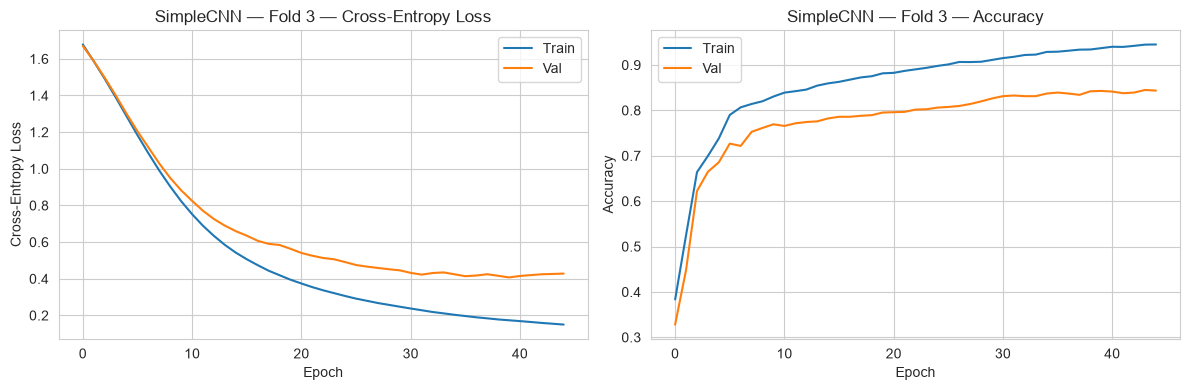

  Early stopping at epoch 41


--- Fold 4 | val subjects [np.int64(6), np.int64(14), np.int64(26), np.int64(28)] | best epoch 36 | Val Acc 0.8080 | Val macro-F1 0.8092


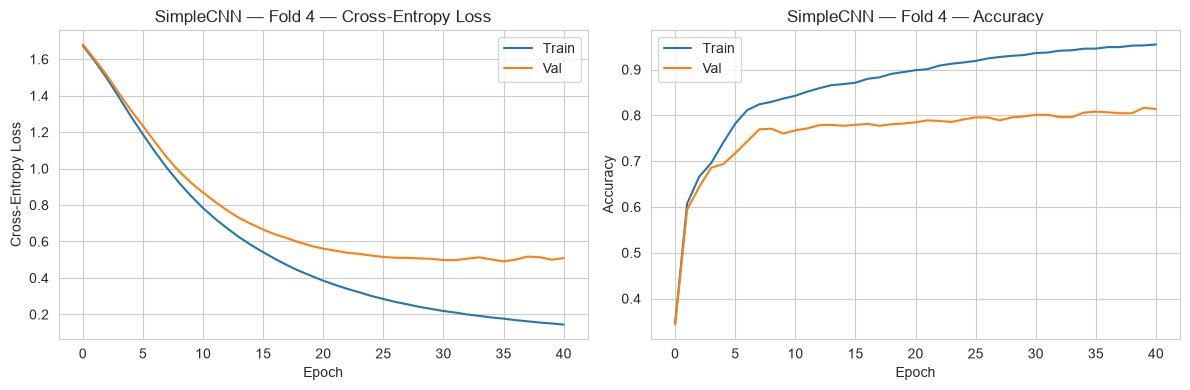

  Early stopping at epoch 83


--- Fold 5 | val subjects [np.int64(3), np.int64(22), np.int64(27), np.int64(29)] | best epoch 78 | Val Acc 0.9465 | Val macro-F1 0.9437


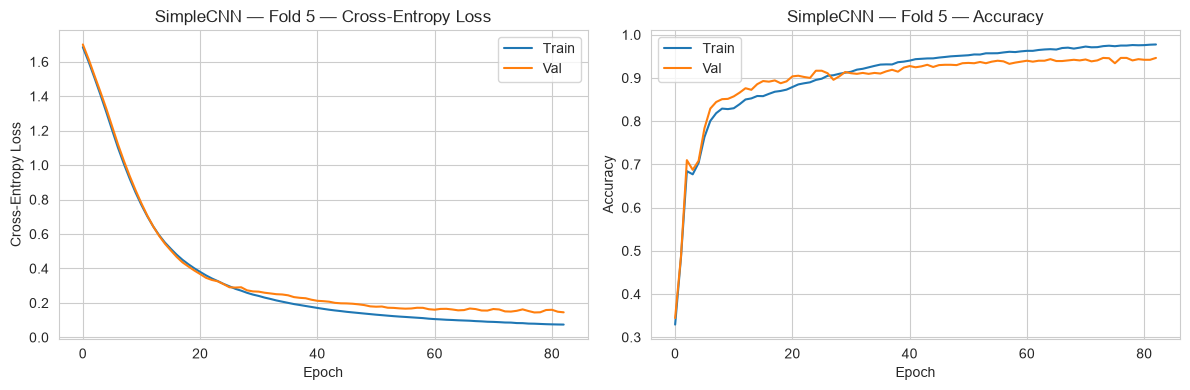


SimpleCNN subject-wise CV accuracy : 0.8732 ± 0.0464
SimpleCNN subject-wise CV macro-F1 : 0.8709 ± 0.0446


In [20]:
# ------------------------------------------------------------------
# 5-fold subject-wise cross-validation for SimpleCNN
# Identical strategy to the SimpleNN section above.
# ------------------------------------------------------------------
cnn_cv_acc, cnn_cv_f1, cnn_best_epochs, cnn_oof_pred = cross_validate_torch(
    lambda: SimpleCNN(N_COMPONENTS, num_classes), 'SimpleCNN', add_channel_dim=True)

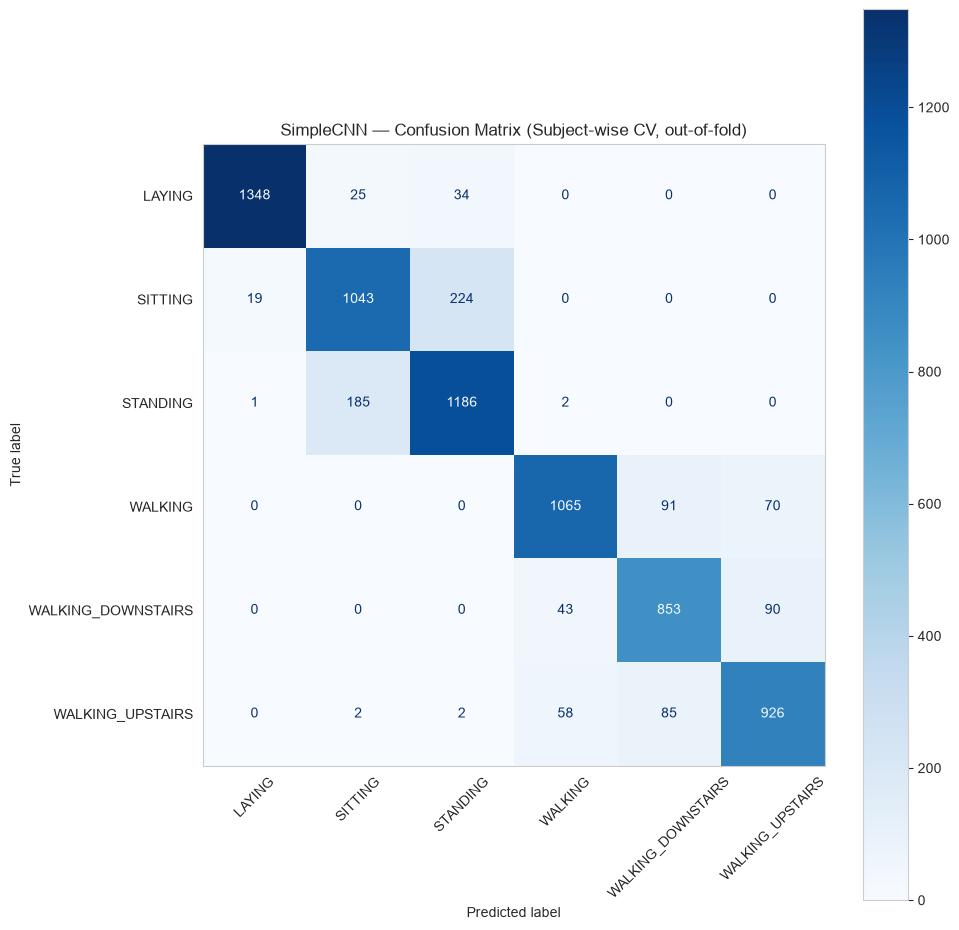

Final SimpleCNN trained for 53 epochs on all 7352 training windows.


In [21]:
# ------------------------------------------------------------------
# Step 1: Pooled out-of-fold confusion matrix
# ------------------------------------------------------------------
plot_confusion(y_encoded, cnn_oof_pred, 'SimpleCNN — Confusion Matrix (Subject-wise CV, out-of-fold)')

# Step 2: Final CNN on all training subjects for the median best CV epoch
cnn_epochs = int(np.median(cnn_best_epochs))
torch.manual_seed(42)
final_cnn = train_final_model(SimpleCNN(N_COMPONENTS, num_classes).to(device),
                              X_tensor.to(device), y_tensor.to(device), cnn_epochs)
torch.save(final_cnn.state_dict(), 'best_model_CNN.pth')
print(f'Final SimpleCNN trained for {cnn_epochs} epochs on all {len(y_tensor)} training windows.')

## 8. Final Evaluation on the Held-Out Test Set

In [22]:
# ------------------------------------------------------------------
# Preprocess the held-out test set using the same transformations
# that were fitted on the training data (scaler and pca_95).
# Applying fit_transform here would cause data leakage.
# ------------------------------------------------------------------

# Step 1: Extract raw features and true activity labels from test_data
X_test_raw      = test_data.drop(columns=['Activity', 'subject'])
activity_labels = test_data['Activity'].values

# Step 2: Encode the string labels using the LabelEncoder fitted on training data
y_test_encoded = le.transform(activity_labels)

# Step 3: Standardise using the scaler fitted on the training features
X_test_scaled = scaler.transform(X_test_raw)

# Step 4: Project into the 100-component PCA space
X_test_pca = pca_95.transform(X_test_scaled)

# Step 5: Wrap in a DataFrame for inspection
pca_df_test = pd.DataFrame(data=X_test_pca,
                           columns=[f'PC{i+1}' for i in range(N_COMPONENTS)])
print('Test PCA DataFrame shape:', pca_df_test.shape)
print(pca_df_test.head())

# Step 6: Convert to tensors and add the channel dimension for the CNN
#         This must happen AFTER pca_df_test is fully constructed.
X_test_tensor = (torch.tensor(pca_df_test.values, dtype=torch.float32)
                 .unsqueeze(1)          # shape: (N, 1, 100)
                 .to(device))
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long).to(device)

print(f'X_test_tensor shape: {X_test_tensor.shape}')
print(f'y_test_tensor shape: {y_test_tensor.shape}')

Test PCA DataFrame shape: (2947, 100)


         PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -10.262280 -1.429259 -1.756266 -1.471646 -3.628867 -0.648441  3.422117   
1 -13.070632 -0.862309  0.407785 -2.961993 -3.346329  1.482588 -0.524768   
2 -14.239412  2.576799  2.190182 -2.474236 -2.239261 -0.638699  1.304945   
3 -14.482305  2.087274  1.640800 -2.595560 -2.902612 -1.654429 -0.030258   
4 -13.776189 -1.402332  1.416319 -2.447932 -3.926211  0.220251 -1.200678   

        PC8       PC9      PC10  ...      PC91      PC92      PC93      PC94  \
0 -2.037576 -2.686782 -1.060198  ...  0.767413 -0.842992  0.011300  0.975412   
1  0.242094  0.602578 -1.924923  ...  0.750517 -1.227106  0.925030  0.485274   
2 -1.683838 -2.656168  1.949818  ...  0.217918 -0.124646  0.492894 -0.081902   
3 -1.147152 -1.490350  1.882322  ...  1.130800  0.101362  0.151746 -0.738524   
4  1.454476 -0.204931 -0.965680  ...  0.246178  0.507967  0.155926 -0.254995   

       PC95      PC96      PC97      PC98      PC99     PC100 

In [23]:
# ------------------------------------------------------------------
# Load the final CNN weights and run inference on the test set
# ------------------------------------------------------------------
input_size  = X_test_tensor.shape[2]  # 100 PCA components
num_classes = len(le.classes_)

model = SimpleCNN(input_size, num_classes).to(device)
model.load_state_dict(torch.load('best_model_CNN.pth', map_location=device))
model.eval()

with torch.no_grad():
    test_outputs     = model(X_test_tensor)
    test_predictions = torch.argmax(test_outputs, dim=1)

y_test_true = y_test_tensor.cpu().numpy()
y_test_pred = test_predictions.cpu().numpy()

                    precision    recall  f1-score   support

            LAYING       1.00      0.99      0.99       537
           SITTING       0.89      0.80      0.84       491
          STANDING       0.83      0.91      0.87       532
           WALKING       0.92      0.94      0.93       496
WALKING_DOWNSTAIRS       0.91      0.87      0.89       420
  WALKING_UPSTAIRS       0.91      0.92      0.91       471

          accuracy                           0.91      2947
         macro avg       0.91      0.90      0.91      2947
      weighted avg       0.91      0.91      0.91      2947

CNN Test Accuracy : 0.9070
CNN Test F1 Score : 0.9068


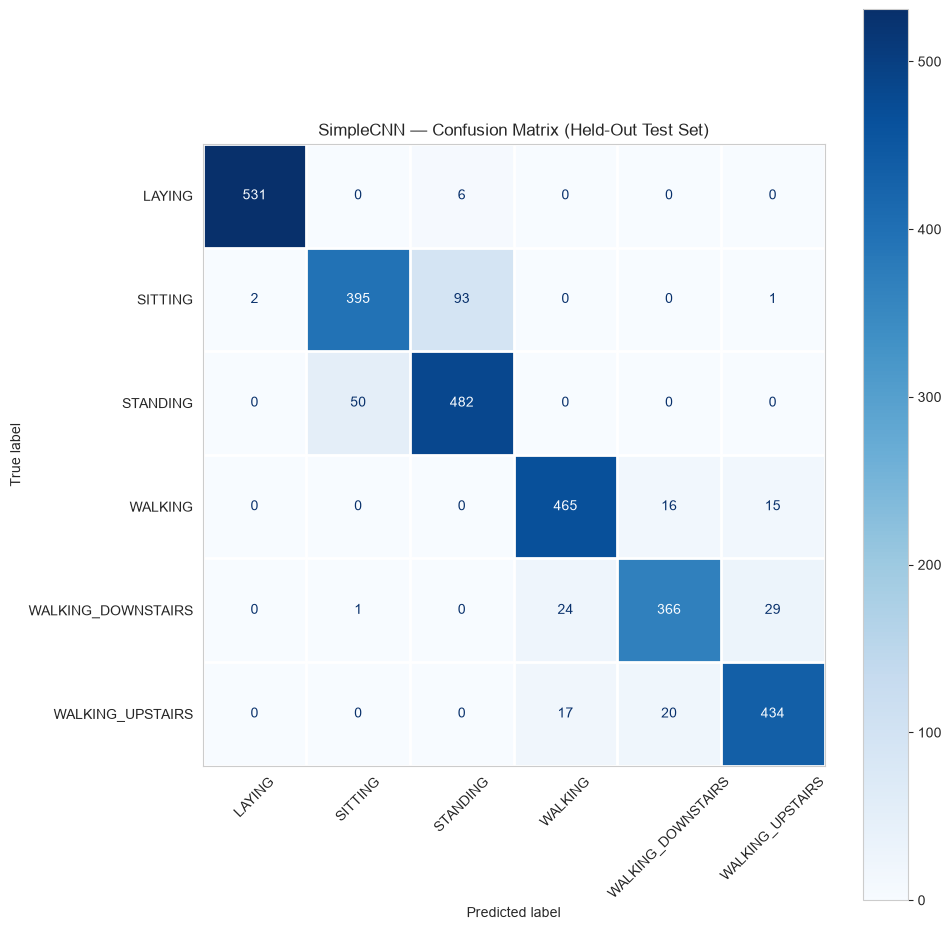

In [24]:
# ------------------------------------------------------------------
# Evaluate CNN performance on the held-out test set
# ------------------------------------------------------------------

# Per-class classification report
print(classification_report(y_test_true, y_test_pred, target_names=le.classes_))

# Summary metrics
test_accuracy = accuracy_score(y_test_true, y_test_pred)
test_f1       = f1_score(y_test_true, y_test_pred, average='weighted')
print(f'CNN Test Accuracy : {test_accuracy:.4f}')
print(f'CNN Test F1 Score : {test_f1:.4f}')

# Confusion matrix
cm = confusion_matrix(y_test_true, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title('SimpleCNN — Confusion Matrix (Held-Out Test Set)')
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', size=0)
plt.tight_layout()
plt.show()


## 9. PCA with 30 Components — Component Analysis & SVM

Transformed training set shape : (7352, 30)
Variance explained by 30 PCs  : 81.78%
Variance explained by 100 PCs : 94.89%  (reference)


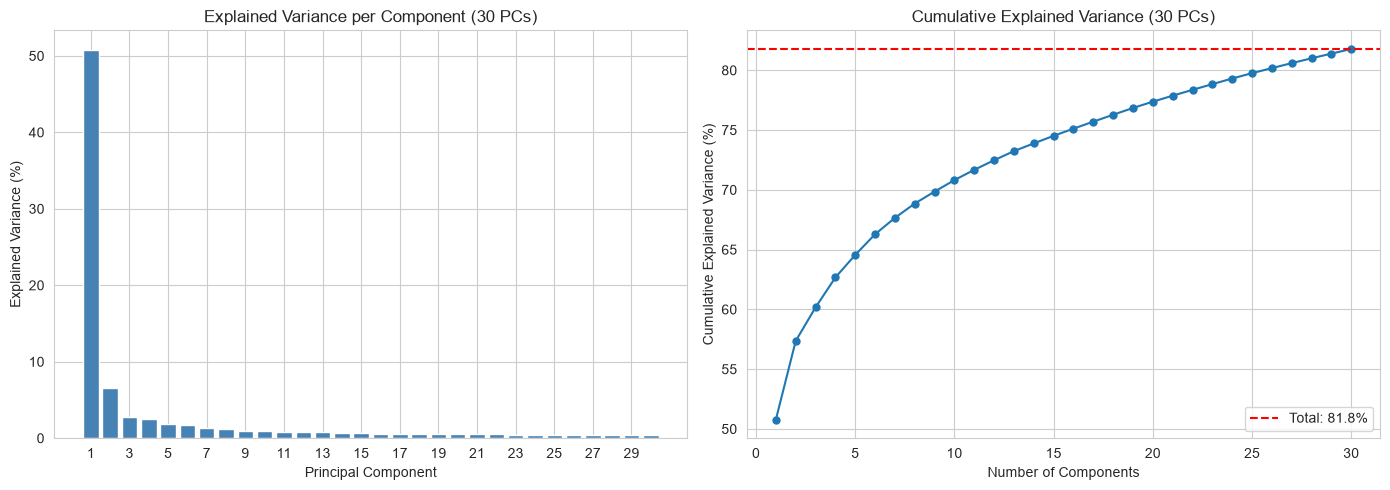

In [25]:
# ------------------------------------------------------------------
# Step 1: Fit PCA with 30 components on the same standardised
# training features used in Section 4.
# scaled_features and scaler are already available from above.
# ------------------------------------------------------------------
N_COMPONENTS_30 = 30
pca_30 = PCA(n_components=N_COMPONENTS_30)
pca_result_30 = pca_30.fit_transform(scaled_features)

total_var_30 = pca_30.explained_variance_ratio_.sum()
print(f"Transformed training set shape : {pca_result_30.shape}")
print(f"Variance explained by 30 PCs  : {total_var_30*100:.2f}%")
print(f"Variance explained by 100 PCs : {pca_95.explained_variance_ratio_.sum()*100:.2f}%  (reference)")

# Step 2: Per-component and cumulative explained variance plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, N_COMPONENTS_30 + 1),
            pca_30.explained_variance_ratio_ * 100, color="steelblue")
axes[0].set_title("Explained Variance per Component (30 PCs)")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_xticks(range(1, N_COMPONENTS_30 + 1, 2))

cumvar_30 = np.cumsum(pca_30.explained_variance_ratio_) * 100
axes[1].plot(range(1, N_COMPONENTS_30 + 1), cumvar_30, marker="o", markersize=5)
axes[1].axhline(y=total_var_30 * 100, color="r", linestyle="--",
                label=f"Total: {total_var_30*100:.1f}%")
axes[1].set_title("Cumulative Explained Variance (30 PCs)")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

Top 8 features (highest absolute loading) for PC1 to PC5:

PC1:
  fBodyAcc-sma()                              loading = +0.0586
  fBodyAccJerk-sma()                          loading = +0.0586
  tBodyAccJerk-sma()                          loading = +0.0585
  fBodyGyro-sma()                             loading = +0.0585
  tBodyAccJerkMag-mean()                      loading = +0.0585
  tBodyAccJerkMag-sma()                       loading = +0.0585
  fBodyBodyAccJerkMag-sma()                   loading = +0.0581
  fBodyBodyAccJerkMag-mean()                  loading = +0.0581

PC2:
  fBodyAcc-meanFreq()-Z                       loading = +0.1224
  tBodyGyroMag-arCoeff()1                     loading = +0.1198
  tBodyAccMag-arCoeff()1                      loading = +0.1182
  tGravityAccMag-arCoeff()1                   loading = +0.1182
  fBodyAccMag-meanFreq()                      loading = +0.1179
  tGravityAcc-arCoeff()-Z,1                   loading = +0.1176
  tGravityAcc-arCoeff()-Z,2       

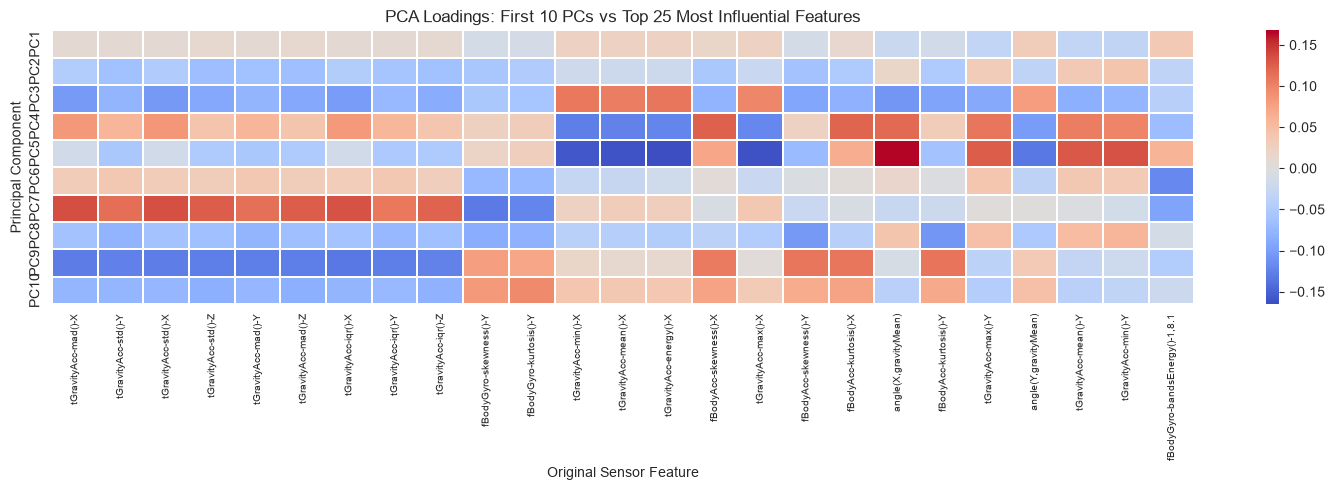

In [26]:
# ------------------------------------------------------------------
# Step 1: Inspect which original sensor features drive each PC.
# pca_30.components_ has shape (30, 561):
#   rows = principal components, columns = original features.
# ------------------------------------------------------------------
feature_names = list(X_raw.columns)
components    = pca_30.components_

# Step 2: Print the top 8 loading features for the first 5 PCs
print("Top 8 features (highest absolute loading) for PC1 to PC5:")
print()
for pc_idx in range(5):
    top_idx = np.argsort(np.abs(components[pc_idx]))[::-1][:8]
    print(f"PC{pc_idx + 1}:")
    for i in top_idx:
        print(f"  {feature_names[i]:<42s}  loading = {components[pc_idx][i]:+.4f}")
    print()

# Step 3: Heatmap — first 10 PCs vs the 25 features with the
# highest total absolute loading across those PCs.
N_PCS_SHOWN  = 10
N_FEAT_SHOWN = 25

overall_abs = np.sum(np.abs(components[:N_PCS_SHOWN, :]), axis=0)
top_feat_idx   = np.argsort(overall_abs)[::-1][:N_FEAT_SHOWN]
top_feat_names = [feature_names[i] for i in top_feat_idx]

loadings_subset = components[:N_PCS_SHOWN, top_feat_idx]

plt.figure(figsize=(15, 5))
sns.heatmap(loadings_subset,
            xticklabels=top_feat_names,
            yticklabels=[f"PC{i+1}" for i in range(N_PCS_SHOWN)],
            cmap="coolwarm", center=0, linewidths=0.3)
plt.title(f"PCA Loadings: First {N_PCS_SHOWN} PCs vs Top {N_FEAT_SHOWN} Most Influential Features")
plt.xlabel("Original Sensor Feature")
plt.ylabel("Principal Component")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()


=== Subject-wise Validation Set: SVM with 30 PCA Components ===
                    precision    recall  f1-score   support

            LAYING       1.00      0.96      0.98       331
           SITTING       0.82      0.90      0.86       293
          STANDING       0.90      0.86      0.88       321
           WALKING       0.93      1.00      0.97       338
WALKING_DOWNSTAIRS       0.98      0.72      0.83       242
  WALKING_UPSTAIRS       0.85      0.99      0.91       276

          accuracy                           0.91      1801
         macro avg       0.91      0.90      0.90      1801
      weighted avg       0.92      0.91      0.91      1801



=== Held-Out Test Set: SVM with 30 PCA Components ===
                    precision    recall  f1-score   support

            LAYING       1.00      0.96      0.98       537
           SITTING       0.86      0.81      0.83       491
          STANDING       0.84      0.92      0.88       532
           WALKING       0.90      0.94      0.92       496
WALKING_DOWNSTAIRS       0.96      0.80      0.87       420
  WALKING_UPSTAIRS       0.84      0.92      0.88       471

          accuracy                           0.89      2947
         macro avg       0.90      0.89      0.89      2947
      weighted avg       0.90      0.89      0.89      2947



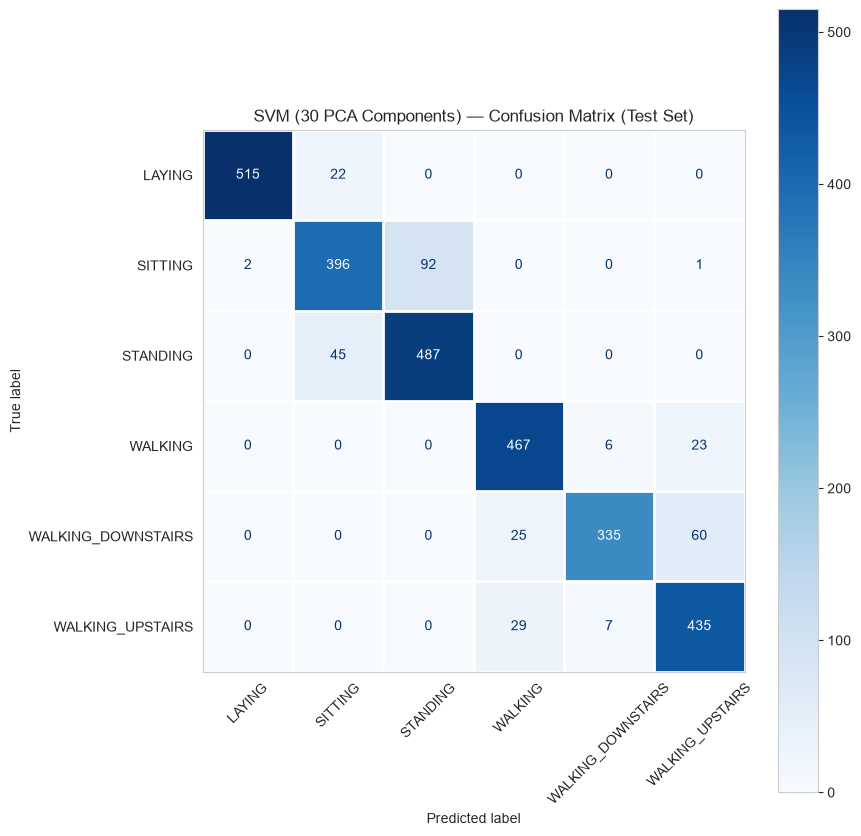

SVM (PCA-30)  | Val  Acc: 0.9100  F1: 0.9087
SVM (PCA-30)  | Test Acc: 0.8941  F1: 0.8940
SVM (PCA-100) | Val  Acc: 0.9461  F1: 0.9458  [Section 5 reference]


In [27]:
# ------------------------------------------------------------------
# Step 1: Validate on the subject-wise hold-out split. Scaler + PCA-30
# are fitted on the training subjects only (pipeline).
# ------------------------------------------------------------------
svm_pca30_val = make_svm_pipeline(N_COMPONENTS_30).fit(X_raw.iloc[tr_idx], y_encoded[tr_idx])
y_pred_val_30 = svm_pca30_val.predict(X_raw.iloc[va_idx])
print("=== Subject-wise Validation Set: SVM with 30 PCA Components ===")
print(classification_report(y_encoded[va_idx], y_pred_val_30, target_names=le.classes_))
val_acc_pca30 = accuracy_score(y_encoded[va_idx], y_pred_val_30)
val_f1_pca30  = f1_score(y_encoded[va_idx], y_pred_val_30, average="weighted")

# Step 2: Final model on all training subjects, evaluated on the test set
svm_pca30 = make_svm_pipeline(N_COMPONENTS_30).fit(X_raw, y_encoded)
y_pred_test_30 = svm_pca30.predict(X_test_raw)
print("=== Held-Out Test Set: SVM with 30 PCA Components ===")
print(classification_report(y_test_encoded, y_pred_test_30, target_names=le.classes_))
test_acc_pca30 = accuracy_score(y_test_encoded, y_pred_test_30)
test_f1_pca30  = f1_score(y_test_encoded, y_pred_test_30, average="weighted")

# Confusion matrix on the test set
cm = confusion_matrix(y_test_encoded, y_pred_test_30)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title("SVM (30 PCA Components) — Confusion Matrix (Test Set)")
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", size=0)
plt.tight_layout()
plt.show()

print(f"SVM (PCA-30)  | Val  Acc: {val_acc_pca30:.4f}  F1: {val_f1_pca30:.4f}")
print(f"SVM (PCA-30)  | Test Acc: {test_acc_pca30:.4f}  F1: {test_f1_pca30:.4f}")
print(f"SVM (PCA-100) | Val  Acc: {svm_accuracy:.4f}  F1: {svm_f1:.4f}  [Section 5 reference]")

## 10. Random Forest Feature Importance — Top 30 Features & SVM

Training Random Forest on all 561 original features ...


Training complete.

Top 30 features by Random Forest importance:
Rank  Feature                                         Importance
----------------------------------------------------------------
1     tGravityAcc-mean()-X                              0.040689
2     tGravityAcc-min()-X                               0.032566
3     tGravityAcc-mean()-Y                              0.029432
4     angle(X,gravityMean)                              0.026287
5     tGravityAcc-energy()-X                            0.024667
6     angle(Y,gravityMean)                              0.023440
7     tGravityAcc-max()-X                               0.022468
8     tGravityAcc-min()-Y                               0.021728
9     tGravityAcc-max()-Y                               0.018757
10    tGravityAccMag-std()                              0.015723
11    tGravityAcc-energy()-Y                            0.015646
12    angle(Z,gravityMean)                              0.011475
13    tGravityAcc-arCoeff

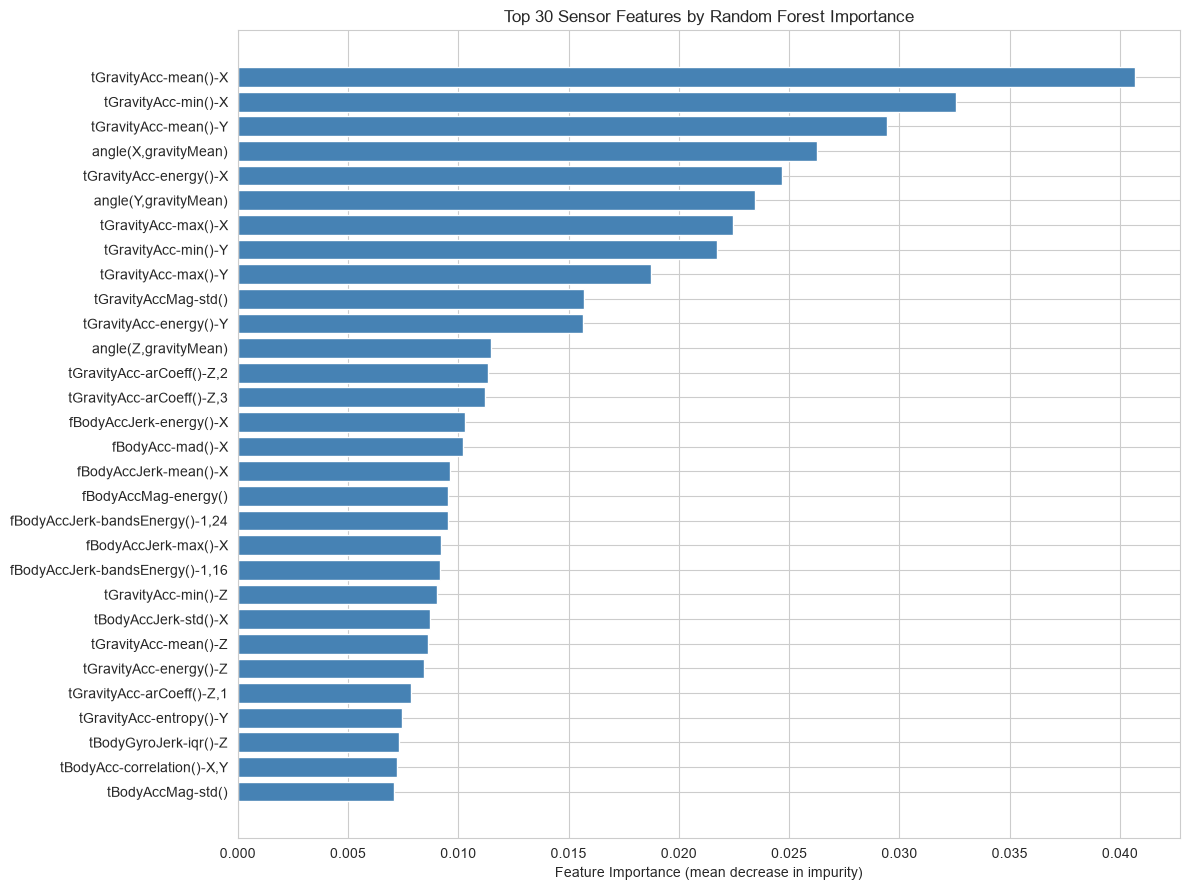

In [28]:
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------------
# Step 1: Train a Random Forest on the standardised training data.
# X_scaled (N x 561) and y_encoded are from Section 3.
# RF is scale-invariant, so the pre-scaled features are fine.
# ------------------------------------------------------------------
print("Training Random Forest on all 561 original features ...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y_encoded)
print("Training complete.")

# Step 2: Rank features by mean decrease in impurity (Gini importance)
feature_names_rf  = list(X_raw.columns)
importances       = rf.feature_importances_
sorted_idx        = np.argsort(importances)[::-1]

TOP_N             = 30
top30_idx         = sorted_idx[:TOP_N]
top30_names       = [feature_names_rf[i] for i in top30_idx]
top30_importances = importances[top30_idx]

print('\nTop ' + str(TOP_N) + ' features by Random Forest importance:')
print('{:<5} {:<45} {:>12}'.format('Rank', 'Feature', 'Importance'))
print('-' * 64)
for rank, (name, imp) in enumerate(zip(top30_names, top30_importances), 1):
    print('{:<5} {:<45} {:>12.6f}'.format(rank, name, imp))

# Step 3: Horizontal bar chart (most important at the top)
plt.figure(figsize=(12, 9))
plt.barh(range(TOP_N - 1, -1, -1), top30_importances, color='steelblue')
plt.yticks(range(TOP_N - 1, -1, -1), top30_names)
plt.xlabel('Feature Importance (mean decrease in impurity)')
plt.title('Top ' + str(TOP_N) + ' Sensor Features by Random Forest Importance')
plt.tight_layout()
plt.show()

=== Subject-wise Validation Set: SVM with Top 30 RF Features ===
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       331
           SITTING       0.90      1.00      0.95       293
          STANDING       1.00      0.90      0.95       321
           WALKING       0.92      1.00      0.96       338
WALKING_DOWNSTAIRS       1.00      0.68      0.81       242
  WALKING_UPSTAIRS       0.85      1.00      0.92       276

          accuracy                           0.94      1801
         macro avg       0.95      0.93      0.93      1801
      weighted avg       0.95      0.94      0.94      1801



=== Held-Out Test Set: SVM with Top 30 RF Features ===
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.86      0.74      0.79       491
          STANDING       0.79      0.89      0.84       532
           WALKING       0.83      0.96      0.89       496
WALKING_DOWNSTAIRS       0.96      0.87      0.91       420
  WALKING_UPSTAIRS       0.86      0.80      0.83       471

          accuracy                           0.88      2947
         macro avg       0.88      0.87      0.88      2947
      weighted avg       0.88      0.88      0.88      2947



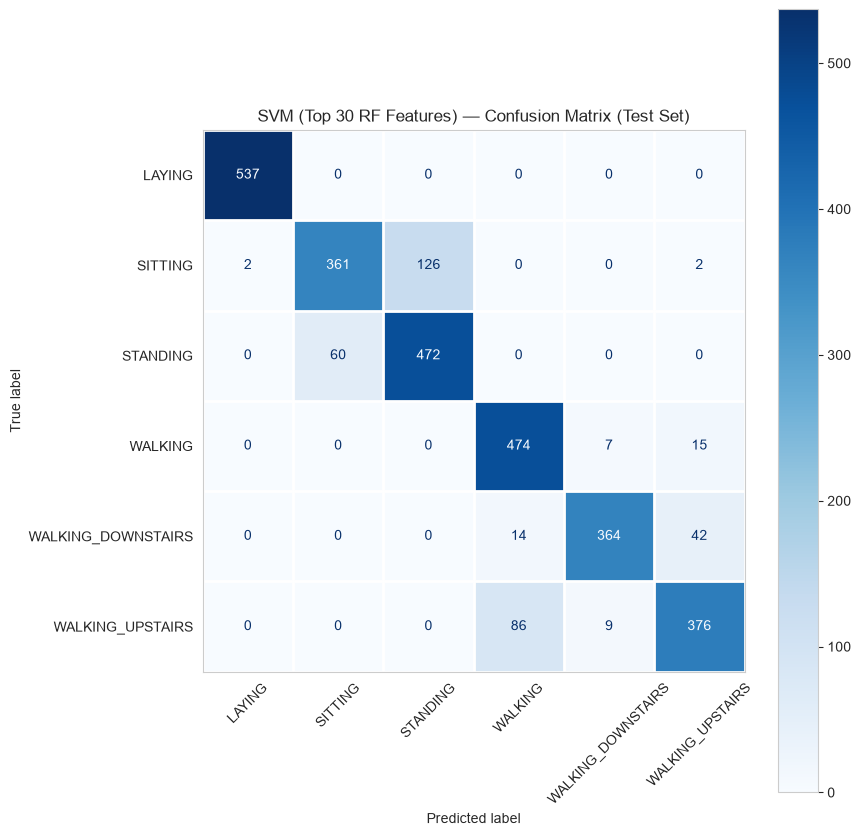

SVM (RF-30 features) | Val  Acc: 0.9389  F1: 0.9363
SVM (RF-30 features) | Test Acc: 0.8768  F1: 0.8761


In [29]:
# ------------------------------------------------------------------
# Step 1: Pipeline = scaler -> keep the 30 most important RF features -> SVM.
# Inside a pipeline the RF ranking is recomputed on whichever subjects the
# pipeline is trained on, so validation subjects never influence selection.
# ------------------------------------------------------------------
def make_rf30_svm_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectFromModel(
            RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
            max_features=TOP_N, threshold=-np.inf)),
        ('svm',    SVC(kernel='rbf', C=1, gamma='scale', random_state=42)),
    ])

# Step 2: Validate on the subject-wise hold-out split
svm_rf30_val  = make_rf30_svm_pipeline().fit(X_raw.iloc[tr_idx], y_encoded[tr_idx])
y_pred_val_rf = svm_rf30_val.predict(X_raw.iloc[va_idx])
print("=== Subject-wise Validation Set: SVM with Top 30 RF Features ===")
print(classification_report(y_encoded[va_idx], y_pred_val_rf, target_names=le.classes_))
val_acc_rf30 = accuracy_score(y_encoded[va_idx], y_pred_val_rf)
val_f1_rf30  = f1_score(y_encoded[va_idx], y_pred_val_rf, average="weighted")

# Step 3: Final model on all training subjects, evaluated on the test set
svm_rf30 = make_rf30_svm_pipeline().fit(X_raw, y_encoded)
y_pred_test_rf = svm_rf30.predict(X_test_raw)
print("=== Held-Out Test Set: SVM with Top 30 RF Features ===")
print(classification_report(y_test_encoded, y_pred_test_rf, target_names=le.classes_))
test_acc_rf30 = accuracy_score(y_test_encoded, y_pred_test_rf)
test_f1_rf30  = f1_score(y_test_encoded, y_pred_test_rf, average="weighted")

# Confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred_test_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title("SVM (Top 30 RF Features) — Confusion Matrix (Test Set)")
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", size=0)
plt.tight_layout()
plt.show()

print(f"SVM (RF-30 features) | Val  Acc: {val_acc_rf30:.4f}  F1: {val_f1_rf30:.4f}")
print(f"SVM (RF-30 features) | Test Acc: {test_acc_rf30:.4f}  F1: {test_f1_rf30:.4f}")

## 11. Full Test-Set Evaluation — All Models Compared

=== SVM (100 PCA components) — Held-Out Test Set ===
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.93      0.88      0.90       491
          STANDING       0.90      0.94      0.92       532
           WALKING       0.94      0.97      0.96       496
WALKING_DOWNSTAIRS       0.97      0.89      0.92       420
  WALKING_UPSTAIRS       0.89      0.94      0.92       471

          accuracy                           0.94      2947
         macro avg       0.94      0.93      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



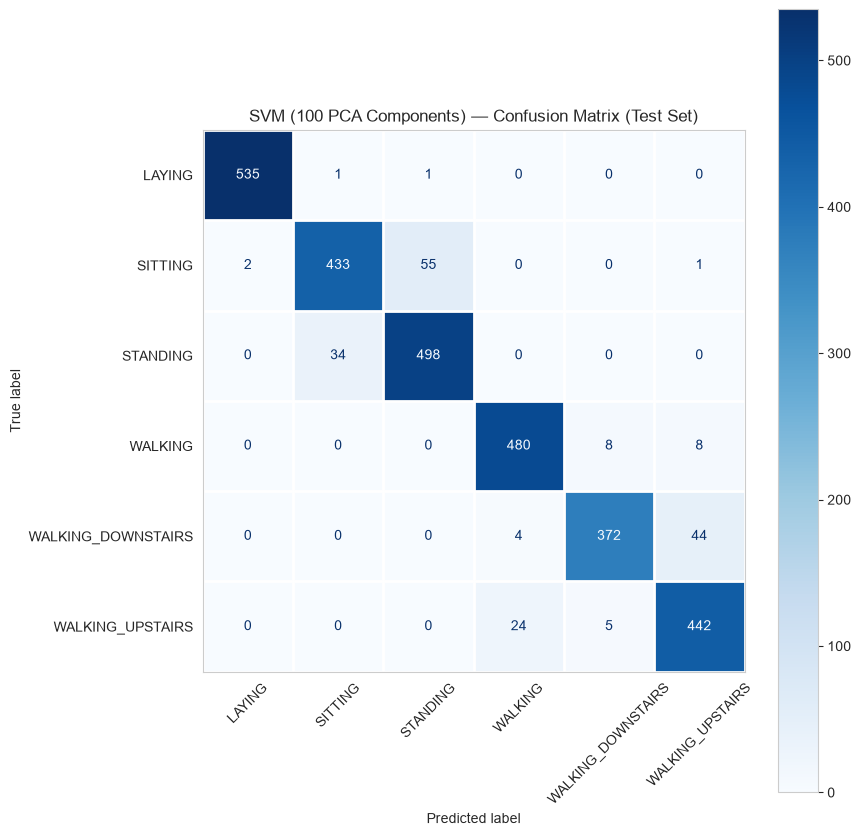

SVM (PCA-100) | Test Acc: 0.9365  Test F1: 0.9365


In [30]:
# ------------------------------------------------------------------
# SVM with 100 PCA components — final pipeline refitted on all training
# subjects, then evaluated on the held-out test subjects.
# ------------------------------------------------------------------
svm_final = make_svm_pipeline().fit(X_raw, y_encoded)
X_test_pca_100 = pca_95.transform(scaler.transform(X_test_raw))   # used by SimpleNN below

y_pred_test_svm100 = svm_final.predict(X_test_raw)
print("=== SVM (100 PCA components) — Held-Out Test Set ===")
print(classification_report(y_test_encoded, y_pred_test_svm100, target_names=le.classes_))
test_acc_svm100 = accuracy_score(y_test_encoded, y_pred_test_svm100)
test_f1_svm100  = f1_score(y_test_encoded, y_pred_test_svm100, average="weighted")

cm = confusion_matrix(y_test_encoded, y_pred_test_svm100)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title("SVM (100 PCA Components) — Confusion Matrix (Test Set)")
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", size=0)
plt.tight_layout()
plt.show()
print(f"SVM (PCA-100) | Test Acc: {test_acc_svm100:.4f}  Test F1: {test_f1_svm100:.4f}")

=== SimpleNN (100 PCA components) — Held-Out Test Set ===
                    precision    recall  f1-score   support

            LAYING       1.00      0.98      0.99       537
           SITTING       0.91      0.87      0.89       491
          STANDING       0.87      0.92      0.90       532
           WALKING       0.92      0.99      0.96       496
WALKING_DOWNSTAIRS       0.97      0.92      0.94       420
  WALKING_UPSTAIRS       0.95      0.92      0.93       471

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



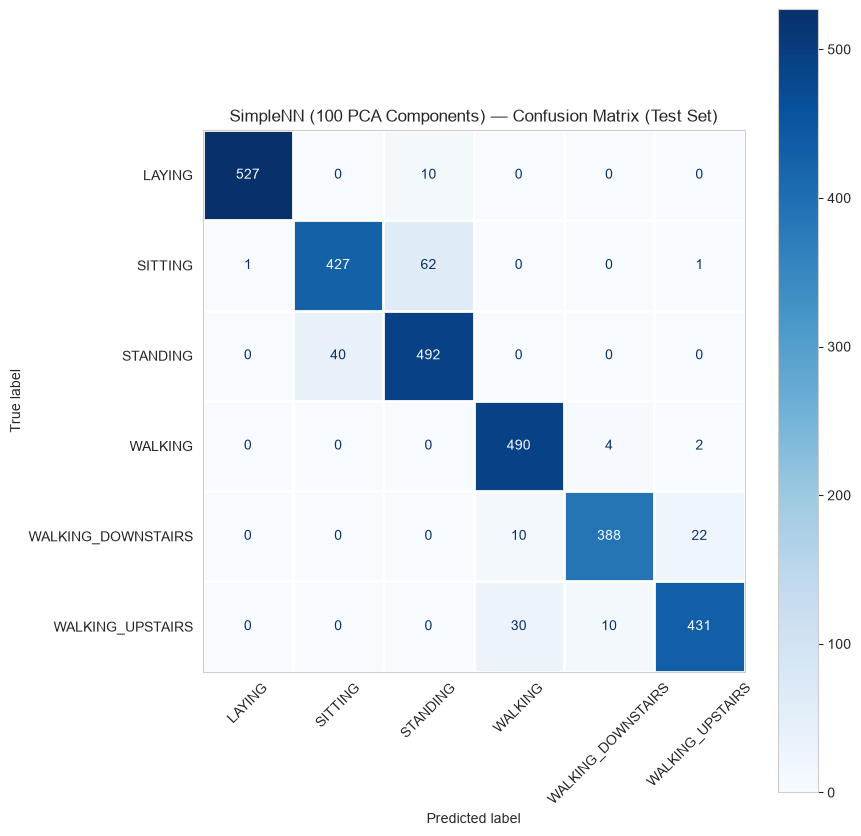

SimpleNN (PCA-100) | Test Acc: 0.9348  Test F1: 0.9349


In [31]:
# ------------------------------------------------------------------
# SimpleNN — held-out test set
# The final NN model was trained after cross-validation (Section 6).
# Test features are the same 100-component PCA space.
# ------------------------------------------------------------------
X_test_nn_tensor = (torch.tensor(X_test_pca_100, dtype=torch.float32)
                    .to(device))

best_nn_test = SimpleNN(input_size=X_test_pca_100.shape[1],
                        num_classes=len(le.classes_)).to(device)
best_nn_test.load_state_dict(torch.load("best_model_NN.pth", map_location=device))
best_nn_test.eval()

with torch.no_grad():
    nn_test_out  = best_nn_test(X_test_nn_tensor)
    nn_test_pred = torch.argmax(nn_test_out, dim=1).cpu().numpy()

print("=== SimpleNN (100 PCA components) — Held-Out Test Set ===")
print(classification_report(y_test_encoded, nn_test_pred, target_names=le.classes_))
test_acc_nn = accuracy_score(y_test_encoded, nn_test_pred)
test_f1_nn  = f1_score(y_test_encoded, nn_test_pred, average="weighted")

cm = confusion_matrix(y_test_encoded, nn_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=45)
plt.title("SimpleNN (100 PCA Components) — Confusion Matrix (Test Set)")
ax.grid(False)
ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", size=0)
plt.tight_layout()
plt.show()
print(f"SimpleNN (PCA-100) | Test Acc: {test_acc_nn:.4f}  Test F1: {test_f1_nn:.4f}")

In [32]:
# ------------------------------------------------------------------
# Comparison of every model on the held-out test set (9 unseen subjects).
# "Subject-wise CV" is the leak-free estimate from 5-fold
# StratifiedGroupKFold on the training subjects ("–" = hold-out only).
# ------------------------------------------------------------------
rows = [
    # (model, feature set, CV fold accuracies, test predictions)
    ("SVM",      "PCA-100",            svm_cv_acc, y_pred_test_svm100),
    ("SimpleNN", "PCA-100",            nn_cv_acc,  nn_test_pred),
    ("CNN",      "PCA-100",            cnn_cv_acc, y_test_pred),
    ("SVM",      "PCA-30",             None,       y_pred_test_30),
    ("SVM",      "Top-30 RF features", None,       y_pred_test_rf),
]

sep = '-' * 82
print(sep)
print('  {:<10} {:<20} {:>17} {:>10} {:>14}'.format(
    'Model', 'Feature set', 'Subject-wise CV', 'Test Acc', 'Test macro-F1'))
print(sep)
results = []
for model_name, feats, cv_acc, pred in rows:
    cv_str = f'{cv_acc.mean():.4f} ± {cv_acc.std():.4f}' if cv_acc is not None else '–'
    acc = accuracy_score(y_test_encoded, pred)
    f1m = f1_score(y_test_encoded, pred, average='macro')
    results.append((model_name, feats, acc))
    print('  {:<10} {:<20} {:>17} {:>10.4f} {:>14.4f}'.format(model_name, feats, cv_str, acc, f1m))
print(sep)

best = max(results, key=lambda r: r[2])
print(f'\nBest test accuracy: {best[0]} ({best[1]})  ->  {best[2]:.4f}')

----------------------------------------------------------------------------------
  Model      Feature set            Subject-wise CV   Test Acc  Test macro-F1
----------------------------------------------------------------------------------
  SVM        PCA-100                0.9097 ± 0.0392     0.9365         0.9353
  SimpleNN   PCA-100                0.9072 ± 0.0511     0.9348         0.9347
  CNN        PCA-100                0.8732 ± 0.0464     0.9070         0.9057


  SVM        PCA-30                               –     0.8941         0.8923
  SVM        Top-30 RF features                   –     0.8768         0.8752
----------------------------------------------------------------------------------

Best test accuracy: SVM (PCA-100)  ->  0.9365
